# 05 - Simple RAG

Minimal dense-retrieval RAG baseline for the legal QA benchmark.

In [1]:
import json
import sys
from time import perf_counter
from pathlib import Path

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    if ROOT.parent == ROOT:
        raise RuntimeError('Project root not found')
    ROOT = ROOT.parent

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from legal_rag.simple_rag import SimpleRagConfig, load_index_manifest, resolve_collection_name, run_simple_rag
from legal_rag.oracle_context_evaluation.io import read_jsonl
from legal_rag.simple_rag.retrieval import connect_qdrant

INDEX_MANIFEST = ROOT / 'data/indexing_runs/<latest>/index_manifest.json'
SMOKE_OUTPUT = ROOT / 'data/rag_runs/simple_smoke'
FULL_OUTPUT = ROOT / 'data/rag_runs/simple'

BASE_CONFIG = {
    'evaluation_dir': str(ROOT / 'data/evaluation_clean'),
    'index_manifest_path': str(INDEX_MANIFEST),
    'static_filters': {'law_status': 'current'},
    'top_k': 3,
    'max_context_chunks': 3,
    'max_context_chars': 8000,
    'max_concurrency': 8,
    'show_progress': True,
    'progress_interval': 5,
    'retry_attempts': 2,
    'timeout_seconds': 180,
}

def metric_rows(summary):
    rows = []
    for dataset, label in [('mcq', 'MCQ'), ('no_hint', 'No-hint')]:
        metrics = summary[dataset]
        rows.append({
            'dataset': label,
            'processed': metrics['processed'],
            'judged': metrics['judged'],
            'errors': metrics['errors'],
            'accuracy': metrics['accuracy'],
            'mean_score': metrics['mean_score'],
            'strict_accuracy': metrics['strict_accuracy'],
            'coverage': metrics['coverage'],
            'score_sum': metrics['score_sum'],
            'max_score_sum': metrics['max_score_sum'],
        })
    return rows

def comparison_rows(simple_summary, no_rag_summary):
    rows = []
    for dataset, label, primary_metric in [('mcq', 'MCQ', 'accuracy'), ('no_hint', 'No-hint', 'mean_score')]:
        rag_value = simple_summary[dataset][primary_metric]
        no_rag_value = no_rag_summary[dataset][primary_metric]
        rows.append({
            'dataset': label,
            'metric': primary_metric,
            'no_rag': no_rag_value,
            'simple_rag': rag_value,
            'delta': None if rag_value is None or no_rag_value is None else rag_value - no_rag_value,
            'rag_errors': simple_summary[dataset]['errors'],
            'no_rag_errors': no_rag_summary[dataset]['errors'],
        })
    return rows

def _format_value(value):
    if value is None:
        return 'n/a'
    if isinstance(value, float):
        return f'{value:.3f}'
    return str(value)

def print_table(title, rows):
    if not rows:
        print(f'{title}: no rows')
        return
    columns = list(rows[0].keys())
    widths = {column: max(len(column), *(len(_format_value(row[column])) for row in rows)) for column in columns}
    print(f'\n{title}')
    print(' | '.join(column.ljust(widths[column]) for column in columns))
    print('-+-'.join('-' * widths[column] for column in columns))
    for row in rows:
        print(' | '.join(_format_value(row[column]).ljust(widths[column]) for column in columns))

def plot_rag_vs_no_rag(simple_summary, no_rag_summary, *, output_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    colors = {'No-RAG': '#8a8f98', 'Simple RAG': '#2f6f9f'}

    panels = [
        (axes[0], 'MCQ accuracy', 'mcq', 'accuracy', (0, 1)),
        (axes[1], 'No-hint mean score', 'no_hint', 'mean_score', (0, 2)),
    ]

    for ax, title, dataset, metric, ylim in panels:
        values = [no_rag_summary[dataset][metric], simple_summary[dataset][metric]]
        labels = ['No-RAG', 'Simple RAG']
        bars = ax.bar(labels, values, color=[colors[label] for label in labels], width=0.58)
        ax.set_title(title)
        ax.set_ylim(*ylim)
        ax.grid(axis='y', alpha=0.25)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_ylabel(metric)
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                'n/a' if value is None else f'{value:.3f}',
                ha='center',
                va='bottom',
                fontsize=10,
            )

    fig.suptitle('Simple RAG vs No-RAG baseline', fontsize=13)
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=160, bbox_inches='tight')
        print(f'Chart saved to: {output_path}')
    return fig

## Preflight

In [2]:
cfg = SimpleRagConfig(**BASE_CONFIG)
index_manifest_path, index_manifest = load_index_manifest(cfg)
collection_name = resolve_collection_name(cfg, index_manifest)
qdrant_client = connect_qdrant(cfg, index_manifest)
collection_info = qdrant_client.get_collection(collection_name)
qdrant_client.close()

preflight = {
    'evaluation_mcq_rows': sum(1 for _ in (ROOT / 'data/evaluation_clean/questions_mcq.jsonl').open(encoding='utf-8')),
    'evaluation_no_hint_rows': sum(1 for _ in (ROOT / 'data/evaluation_clean/questions_no_hint.jsonl').open(encoding='utf-8')),
    'index_manifest': str(index_manifest_path),
    'collection_name': collection_name,
    'collection_points': collection_info.points_count,
    'full_output': str(FULL_OUTPUT),
    'config': BASE_CONFIG,
}
display(preflight)

{'evaluation_mcq_rows': 100,
 'evaluation_no_hint_rows': 100,
 'index_manifest': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexing_runs/20260505_084836/index_manifest.json',
 'collection_name': 'legal_chunks',
 'collection_points': 76467,
 'full_output': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/rag_runs/simple',
 'config': {'evaluation_dir': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/evaluation_clean',
  'index_manifest_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexing_runs/<latest>/index_manifest.json',
  'static_filters': {'law_status': 'current'},
  'top_k': 3,
  'max_context_chunks': 3,
  'max_context_chars': 8000,
  'max_concurrency': 8,
  'show_progress': True,
  'progress_interval': 5,
  're

## Smoke Run

In [3]:
print('Starting smoke run...')
started = perf_counter()
smoke_manifest = run_simple_rag(
    SimpleRagConfig(
        **BASE_CONFIG,
        output_dir=str(SMOKE_OUTPUT),
        smoke=True,
    )
)
print(f"Smoke run completed in {perf_counter() - started:.1f}s")
display({
    'output_dir': str(SMOKE_OUTPUT),
    'counts': smoke_manifest['counts'],
    'summary': smoke_manifest['summary'],
})

Starting smoke run...
[simple-rag] index_manifest=/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexing_runs/20260505_084836/index_manifest.json
[simple-rag] collection=legal_chunks
[simple-rag] selected mcq=1 no_hint=1 concurrency=8
[simple-rag] starting MCQ run
[simple-rag mcq] 1/1 (100%) errors=0 elapsed=25s eta=0s
[simple-rag] starting no-hint run
[simple-rag no-hint] 1/1 (100%) errors=0 elapsed=6s eta=0s
[simple-rag] completed in 30s
[simple-rag] output_dir=/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/rag_runs/simple_smoke
Smoke run completed in 30.4s


{'output_dir': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/rag_runs/simple_smoke',
 'counts': {'mcq': 1,
  'no_hint': 1,
  'mcq_errors': 0,
  'no_hint_errors': 0,
  'empty_retrieval': 0,
  'citation_errors': 0},
 'summary': {'mcq': {'dataset': 'mcq',
   'processed': 1,
   'judged': 1,
   'score_sum': 1,
   'max_score_sum': 1,
   'accuracy': 1.0,
   'mean_score': 1.0,
   'coverage': 1.0,
   'strict_accuracy': 1.0,
   'errors': 0,
   'by_level': {'L1': {'processed': 1,
     'judged': 1,
     'score_sum': 1,
     'errors': 0,
     'max_score_sum': 1,
     'accuracy': 1.0,
     'mean_score': 1.0,
     'coverage': 1.0,
     'strict_accuracy': 1.0}}},
  'no_hint': {'dataset': 'no_hint',
   'processed': 1,
   'judged': 1,
   'score_sum': 0,
   'max_score_sum': 2,
   'accuracy': 0.0,
   'mean_score': 0.0,
   'coverage': 1.0,
   'strict_accuracy': 0.0,
   'errors': 0,
   'by_level': {'L1': {'processed': 1,
     'judged': 1,
  

## Inspect One MCQ And One Open Answer

In [4]:
mcq_rows = read_jsonl(SMOKE_OUTPUT / 'mcq_results.jsonl')
no_hint_rows = read_jsonl(SMOKE_OUTPUT / 'no_hint_results.jsonl')

{
    'mcq': mcq_rows[0],
    'no_hint': no_hint_rows[0],
}

{'mcq': {'answer': 'Il direttore generale il collegio sindacale',
  'citations': [{'article_id': 'vda:lr:2002-05-20:5#art:20',
    'chunk_id': 'vda:lr:2002-05-20:5#art:20#p:c1.lit_b#chunk:0',
    'chunk_text': "b) i dipendenti dell'azienda USL, gli operatori legati da rapporto convenzionale con la stessa, coloro che siano comunque legati da un rapporto continuativo di prestazione d'opera retribuita con l'azienda medesima, nonché i suoi fornitori;",
    'law_id': 'vda:lr:2002-05-20:5'}],
  'context_chunk_ids': ['vda:lr:2002-05-20:5#art:44#p:c9#chunk:0',
   'vda:lr:2006-05-19:11#art:6#p:c2#chunk:0',
   'vda:lr:2002-05-20:5#art:20#p:c1.lit_b#chunk:0'],
  'context_count': 3,
  'correct_label': 'D',
  'error': None,
  'level': 'L1',
  'options': {'A': 'Il consiglio regionale',
   'B': 'Il ministro della Salute',
   'C': 'Il presidente della Regione',
   'D': 'Il direttore generale il collegio sindacale',
   'E': 'Il sindaco di Aosta',
   'F': "L'assessore Regionale alla Salute"},
  'predict

## Optional Full Run

In [5]:
RUN_FULL_RAG = True

if RUN_FULL_RAG:
    full_config = SimpleRagConfig(**BASE_CONFIG, output_dir=str(FULL_OUTPUT))
    print('Starting full Simple RAG run...')
    print(f"Output directory: {FULL_OUTPUT}")
    print(f"Concurrency: {full_config.max_concurrency}, top_k: {full_config.top_k}, context_chunks: {full_config.max_context_chunks}")
    started = perf_counter()
    full_manifest = run_simple_rag(full_config)
    elapsed = perf_counter() - started
    print(f"Full Simple RAG run completed in {elapsed:.1f}s")
    print(f"Summary: {FULL_OUTPUT / 'simple_rag_summary.json'}")
    print(f"Quality report: {FULL_OUTPUT / 'quality_report.md'}")
    print_table('Simple RAG performance', metric_rows(full_manifest['summary']))
    display({'counts': full_manifest['counts'], 'summary': full_manifest['summary']})
else:
    print('Set RUN_FULL_RAG = True to run the full benchmark.')

Starting full Simple RAG run...
Output directory: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/rag_runs/simple
Concurrency: 8, top_k: 3, context_chunks: 3
[simple-rag] index_manifest=/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexing_runs/20260505_084836/index_manifest.json
[simple-rag] collection=legal_chunks
[simple-rag] selected mcq=100 no_hint=100 concurrency=8
[simple-rag] starting MCQ run
[simple-rag mcq] 1/100 (1%) errors=0 elapsed=3s eta=5m39s
[simple-rag mcq] 5/100 (5%) errors=0 elapsed=12s eta=3m54s
[simple-rag mcq] 10/100 (10%) errors=0 elapsed=24s eta=3m39s
[simple-rag mcq] 15/100 (15%) errors=0 elapsed=39s eta=3m41s
[simple-rag mcq] 20/100 (20%) errors=0 elapsed=52s eta=3m27s
[simple-rag mcq] 25/100 (25%) errors=0 elapsed=1m04s eta=3m12s
[simple-rag mcq] 30/100 (30%) errors=0 elapsed=1m15s eta=2m56s
[simple-rag mcq] 35/100 (35%) errors=0 

{'counts': {'mcq': 100,
  'no_hint': 100,
  'mcq_errors': 0,
  'no_hint_errors': 0,
  'empty_retrieval': 0,
  'citation_errors': 0},
 'summary': {'mcq': {'dataset': 'mcq',
   'processed': 100,
   'judged': 100,
   'score_sum': 80,
   'max_score_sum': 100,
   'accuracy': 0.8,
   'mean_score': 0.8,
   'coverage': 1.0,
   'strict_accuracy': 0.8,
   'errors': 0,
   'by_level': {'L1': {'processed': 25,
     'judged': 25,
     'score_sum': 19,
     'errors': 0,
     'max_score_sum': 25,
     'accuracy': 0.76,
     'mean_score': 0.76,
     'coverage': 1.0,
     'strict_accuracy': 0.76},
    'L2': {'processed': 25,
     'judged': 25,
     'score_sum': 21,
     'errors': 0,
     'max_score_sum': 25,
     'accuracy': 0.84,
     'mean_score': 0.84,
     'coverage': 1.0,
     'strict_accuracy': 0.84},
    'L3': {'processed': 25,
     'judged': 25,
     'score_sum': 20,
     'errors': 0,
     'max_score_sum': 25,
     'accuracy': 0.8,
     'mean_score': 0.8,
     'coverage': 1.0,
     'strict_accur

## Compare With No-RAG

In [6]:
simple_summary_path = FULL_OUTPUT / 'simple_rag_summary.json'
no_rag_summary_path = ROOT / 'data/baseline_runs/no_rag/no_rag_summary.json'

if simple_summary_path.exists() and no_rag_summary_path.exists():
    simple_summary = json.loads(simple_summary_path.read_text(encoding='utf-8'))
    no_rag_summary = json.loads(no_rag_summary_path.read_text(encoding='utf-8'))
    print_table('Simple RAG performance', metric_rows(simple_summary))
    print_table('Simple RAG vs No-RAG', comparison_rows(simple_summary, no_rag_summary))
    display({
        'simple_rag_summary': str(simple_summary_path),
        'no_rag_summary': str(no_rag_summary_path),
        'comparison': comparison_rows(simple_summary, no_rag_summary),
    })
else:
    print('Run the full simple RAG and no-RAG benchmarks before comparing summaries.')


Simple RAG performance
dataset | processed | judged | errors | accuracy | mean_score | strict_accuracy | coverage | score_sum | max_score_sum
--------+-----------+--------+--------+----------+------------+-----------------+----------+-----------+--------------
MCQ     | 100       | 100    | 0      | 0.800    | 0.800      | 0.800           | 1.000    | 80        | 100          
No-hint | 100       | 100    | 0      | 0.440    | 0.880      | 0.440           | 1.000    | 88        | 200          

Simple RAG vs No-RAG
dataset | metric     | no_rag | simple_rag | delta  | rag_errors | no_rag_errors
--------+------------+--------+------------+--------+------------+--------------
MCQ     | accuracy   | 0.810  | 0.800      | -0.010 | 0          | 0            
No-hint | mean_score | 0.970  | 0.880      | -0.090 | 0          | 0            


{'simple_rag_summary': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/rag_runs/simple/simple_rag_summary.json',
 'no_rag_summary': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/baseline_runs/no_rag/no_rag_summary.json',
 'comparison': [{'dataset': 'MCQ',
   'metric': 'accuracy',
   'no_rag': 0.81,
   'simple_rag': 0.8,
   'delta': -0.010000000000000009,
   'rag_errors': 0,
   'no_rag_errors': 0},
  {'dataset': 'No-hint',
   'metric': 'mean_score',
   'no_rag': 0.97,
   'simple_rag': 0.88,
   'delta': -0.08999999999999997,
   'rag_errors': 0,
   'no_rag_errors': 0}]}

## Comparison Chart

Chart saved to: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/rag_runs/simple/simple_vs_no_rag.png


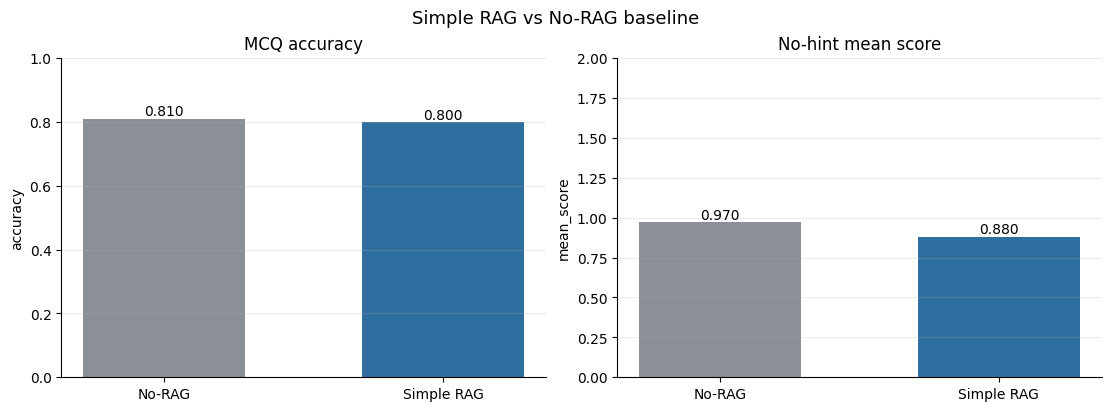

In [7]:
simple_summary_path = FULL_OUTPUT / 'simple_rag_summary.json'
no_rag_summary_path = ROOT / 'data/baseline_runs/no_rag/no_rag_summary.json'
chart_path = FULL_OUTPUT / 'simple_vs_no_rag.png'

if simple_summary_path.exists() and no_rag_summary_path.exists():
    simple_summary = json.loads(simple_summary_path.read_text(encoding='utf-8'))
    no_rag_summary = json.loads(no_rag_summary_path.read_text(encoding='utf-8'))
    fig = plot_rag_vs_no_rag(simple_summary, no_rag_summary, output_path=chart_path)
    display(fig)
    plt.close(fig)
else:
    print('Run the full simple RAG and no-RAG benchmarks before plotting.')